In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix

In [ ]:
df = pd.read_csv('data_decision_tree_bt.csv')
df.head()

,TT,DoHaiLong,LoaiKhachHang,Tuoi,LoaiHinh,DoTrePhut,GheNgoi,ThucAn,GateLocation,DichVuGuiXe,BauKhongKhiTranDau,ChatLuongTranDau,TraiNghiemDatVeOnline,ChatLuongCacDichVuDiKem,DoAnToan,ThoiTiet,SuSachSe,FanDoiNha,ThietKeLoiDi
0,0,Không Hài Lòng,KH Bình Thường,29.0,Đi Cùng Gia Đình/Bạn Bè,15.0,5.0,5.0,4.0,5.0,2.0,5.0,1.0,5.0,5.0,4.0,5.0,4.0,5.0
1,1,Không Hài Lòng,KH Trung Thành,44.0,Đi Cùng Gia Đình/Bạn Bè,0.0,4.0,5.0,5.0,3.0,1.0,4.0,3.0,4.0,3.0,3.0,2.0,3.0,5.0
2,2,Hài Lòng,KH Trung Thành,48.0,Đi Cùng Gia Đình/Bạn Bè,0.0,5.0,2.0,1.0,4.0,2.0,5.0,4.0,5.0,4.0,4.0,4.0,4.0,3.0
3,3,Hài Lòng,KH Bình Thường,45.0,Đi Cùng Gia Đình/Bạn Bè,0.0,5.0,5.0,4.0,3.0,2.0,4.0,3.0,5.0,5.0,5.0,5.0,5.0,3.0
4,4,Không Hài Lòng,KH Trung Thành,49.0,Đi Cá Nhân,0.0,4.0,4.0,2.0,4.0,1.0,5.0,4.0,5.0,4.0,1.0,4.0,2.0,4.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98827 entries, 0 to 98826
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TT                       98827 non-null  int64  
 1   DoHaiLong                98827 non-null  object 
 2   LoaiKhachHang            98826 non-null  object 
 3   Tuoi                     98826 non-null  float64
 4   LoaiHinh                 98826 non-null  object 
 5   DoTrePhut                98524 non-null  float64
 6   GheNgoi                  98826 non-null  float64
 7   ThucAn                   98826 non-null  float64
 8   GateLocation             98826 non-null  float64
 9   DichVuGuiXe              98826 non-null  float64
 10  BauKhongKhiTranDau       98826 non-null  float64
 11  ChatLuongTranDau         98826 non-null  float64
 12  TraiNghiemDatVeOnline    98826 non-null  float64
 13  ChatLuongCacDichVuDiKem  98826 non-null  float64
 14  DoAnToan              

In [ ]:
df.isnull().sum()

,0
TT,0
DoHaiLong,0
LoaiKhachHang,1
Tuoi,1
LoaiHinh,1
DoTrePhut,303
GheNgoi,1
ThucAn,1
GateLocation,1
DichVuGuiXe,1


In [ ]:
df_clean = df.dropna()
df_clean.isnull().sum()

,0
TT,0
DoHaiLong,0
LoaiKhachHang,0
Tuoi,0
LoaiHinh,0
DoTrePhut,0
GheNgoi,0
ThucAn,0
GateLocation,0
DichVuGuiXe,0


In [ ]:
print(df_clean['DoHaiLong'].unique())

['Không Hài Lòng' 'Hài Lòng']


In [ ]:
print(df_clean['DoHaiLong'].value_counts())

DoHaiLong
Hài Lòng          69478
Không Hài Lòng    57416
Name: count, dtype: int64


In [ ]:
print(df_clean['LoaiKhachHang'].unique())

['KH Bình Thường' 'KH Trung Thành']


In [ ]:
print(df_clean['LoaiKhachHang'].value_counts())

LoaiKhachHang
KH Trung Thành    103664
KH Bình Thường     23230
Name: count, dtype: int64


In [ ]:
print(df_clean['LoaiHinh'].unique())

['Đi Cùng Gia Đình/Bạn Bè' 'Đi Cá Nhân']


In [ ]:
print(df_clean['LoaiHinh'].value_counts())

LoaiHinh
Đi Cùng Gia Đình/Bạn Bè    87663
Đi Cá Nhân                 39231
Name: count, dtype: int64


In [ ]:
df_clean_encoded = pd.get_dummies(df_clean, drop_first=True, dtype=int)
df_clean_encoded.head()

,TT,Tuoi,DoTrePhut,GheNgoi,ThucAn,GateLocation,DichVuGuiXe,BauKhongKhiTranDau,ChatLuongTranDau,TraiNghiemDatVeOnline,ChatLuongCacDichVuDiKem,DoAnToan,ThoiTiet,SuSachSe,FanDoiNha,ThietKeLoiDi,DoHaiLong_Không Hài Lòng,LoaiKhachHang_KH Trung Thành,LoaiHinh_Đi Cùng Gia Đình/Bạn Bè
0,0,29.0,15.0,5.0,5.0,4.0,5.0,2.0,5.0,1.0,5.0,5.0,4.0,5.0,4.0,5.0,1,0,1
1,1,44.0,0.0,4.0,5.0,5.0,3.0,1.0,4.0,3.0,4.0,3.0,3.0,2.0,3.0,5.0,1,1,1
2,2,48.0,0.0,5.0,2.0,1.0,4.0,2.0,5.0,4.0,5.0,4.0,4.0,4.0,4.0,3.0,0,1,1
3,3,45.0,0.0,5.0,5.0,4.0,3.0,2.0,4.0,3.0,5.0,5.0,5.0,5.0,5.0,3.0,0,0,1
4,4,49.0,0.0,4.0,4.0,2.0,4.0,1.0,5.0,4.0,5.0,4.0,1.0,4.0,2.0,4.0,1,1,0


In [ ]:
df_clean_encoded = df_clean_encoded.rename(columns={
    'DoHaiLong_Không Hài Lòng' : 'DoHaiLong', # 1: không hài lòng, 0: hài lòng
    'LoaiKhachHang_KH Trung Thành' : 'LoaiKhachHang', # 1: khách hàng trung thành, 0: khách hàng bình thường
    'LoaiHinh_Đi Cùng Gia Đình/Bạn Bè' : 'LoaiHinh' # 1: đi cùng gia đình bạn bè, 0: đi 1 mình
})

In [ ]:
df_clean_encoded.columns

Index(['TT', 'Tuoi', 'DoTrePhut', 'GheNgoi', 'ThucAn', 'GateLocation',
       'DichVuGuiXe', 'BauKhongKhiTranDau', 'ChatLuongTranDau',
       'TraiNghiemDatVeOnline', 'ChatLuongCacDichVuDiKem', 'DoAnToan',
       'ThoiTiet', 'SuSachSe', 'FanDoiNha', 'ThietKeLoiDi', 'DoHaiLong',
       'LoaiKhachHang', 'LoaiHinh'],
      dtype='object')

In [ ]:
Y = df_clean_encoded['DoHaiLong']                       # Nhãn
X = df_clean_encoded.drop(columns=['DoHaiLong', 'TT'])  # Đặc trưng

In [ ]:
print(X.shape)
print(Y.shape)

(98524, 17)
(98524,)


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

In [ ]:
# Tạo 1 mô hình cây quyết định
tree = DecisionTreeClassifier(random_state=1)
# Huấn luyện cây
tree.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
tree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 1,
 'splitter': 'best'}

In [ ]:
Y_pred = tree.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)

print(f'Accuracy: {accuracy:.2f}')
print(f'F1 Score: {f1:.2f}')
print(f'Recall: {recall:.2f}')
print(f'Precision: {precision:.2f}')

Accuracy: 0.89
F1 Score: 0.88
Recall: 0.87
Precision: 0.88


In [ ]:
#100 Khách hàng
#20 Hài lòng => Positive
#80 Không hài lòng => Negative
#Mô hình dự báo:
#15 Khách hàng là Hài Lòng => trong đó 12 người thực sự là hài lòng, 3 người là không hài lòng (nhưng đoán nhầm là hài lòng)
#Bỏ sót 20-12 = 8 khách hàng hài lòng => bị đoán thành không hài lòng (trong khi đúng ra là hài lòng)
#85 KH không hài lòng
#Metrics:
#- Accuracy = (True Positve + True Negative) / Toàn bộ = (12 + 77) / 100
#- Precision = True Positive / (True Positive + False Positive) = 12 / (12 + 3)
#- Recall = True Positive / (True Positive + False Negative) = 12 / (12 + 8)
#- F1 score = 2 * (Precision * Recall) / (Precision + Recall) = 2 * (12 / 15 * 12 / 20) / (15 / 20 + 12 / 20)

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plot_tree(tree, feature_names=X.columns, class_names=['Không Hài Lòng', 'Hài Lòng'], filled=True, max_depth=2)
plt.show()

NameError: name 'tree' is not defined

<Figure size 1500x1000 with 0 Axes>

In [ ]:
tree = DecisionTreeClassifier(random_state=1, max_depth=5, min_samples_split=10, min_samples_leaf=5)
tree.fit(X_train, Y_train)
Y_pred = tree.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)

print(f'Accuracy: {accuracy:.2f}')
print(f'F1 Score: {f1:.2f}')
print(f'Recall: {recall:.2f}')
print(f'Precision: {precision:.2f}')

Accuracy: 0.85
F1 Score: 0.83
Recall: 0.79
Precision: 0.86


In [ ]:
from sklearn.model_selection import GridSearchCV
hyper_params = {
    'max_depth' : [3, 5, 7, 9, 11, 13],
    'min_samples_split' : [5, 10, 15, 20],
    'min_samples_leaf' : [5, 10, 15, 20]
}
tree = DecisionTreeClassifier(random_state=1)
grid_search = GridSearchCV(estimator=tree, param_grid=hyper_params, cv=5, scoring='accuracy')
grid_search.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=1),
             param_grid={'max_depth': [3, 5, 7, 9, 11, 13],
                         'min_samples_leaf': [5, 10, 15, 20],
                         'min_samples_split': [5, 10, 15, 20]},
             scoring='accuracy')

In [ ]:
best_tree = grid_search.best_estimator_
best_tree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 13,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 5,
 'min_samples_split': 20,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 1,
 'splitter': 'best'}

In [ ]:
Y_pred = best_tree.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)

print(f'Accuracy: {accuracy:.2f}')
print(f'F1 Score: {f1:.2f}')
print(f'Recall: {recall:.2f}')
print(f'Precision: {precision:.2f}')

Accuracy: 0.90
F1 Score: 0.89
Recall: 0.88
Precision: 0.90


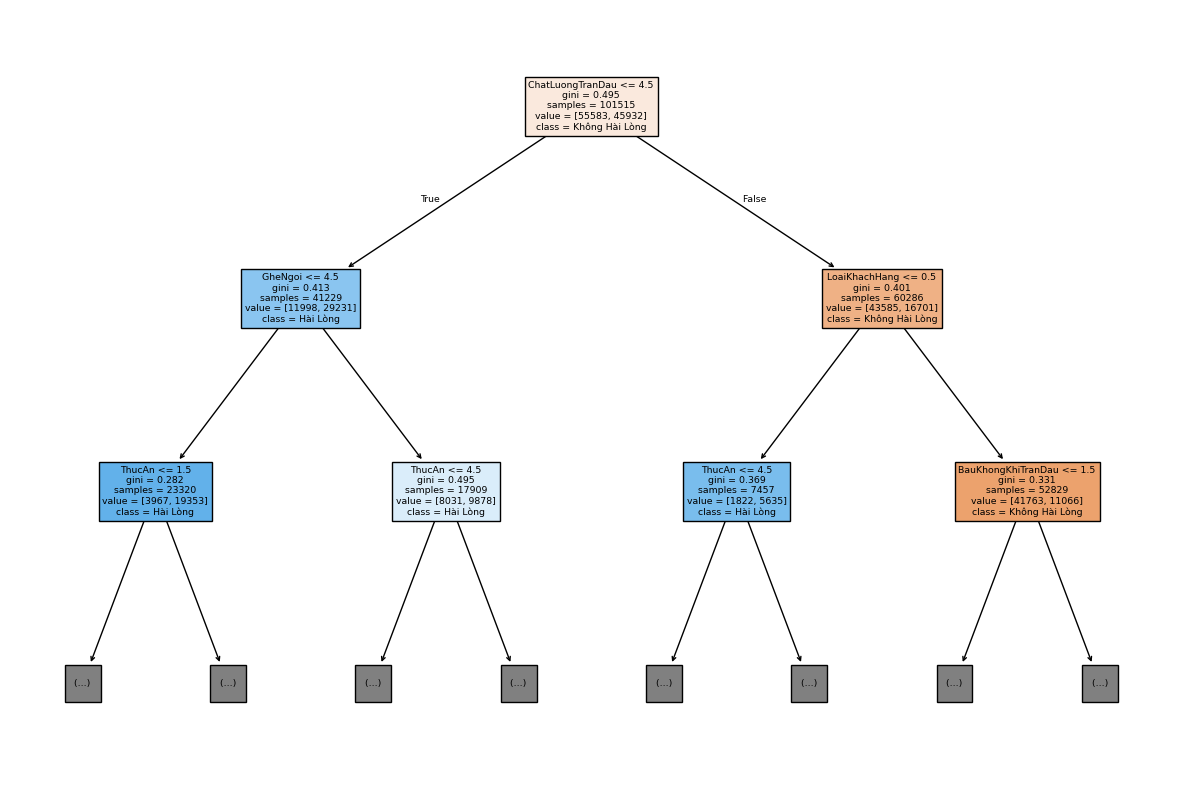

In [ ]:
plt.figure(figsize=(15, 10))
plot_tree(best_tree, feature_names=X.columns, class_names=['Không Hài Lòng', 'Hài Lòng'], filled=True, max_depth=2)
plt.show()

In [ ]:
important_features = best_tree.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': important_features})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

                    Feature  Importance
7          ChatLuongTranDau    0.240111
3                    ThucAn    0.136067
15            LoaiKhachHang    0.115023
6        BauKhongKhiTranDau    0.109062
2                   GheNgoi    0.079515
16                 LoaiHinh    0.061030
9   ChatLuongCacDichVuDiKem    0.060345
4              GateLocation    0.042552
8     TraiNghiemDatVeOnline    0.028022
13                FanDoiNha    0.027499
5               DichVuGuiXe    0.021010
11                 ThoiTiet    0.020788
0                      Tuoi    0.020082
12                 SuSachSe    0.014312
10                 DoAnToan    0.013017
14             ThietKeLoiDi    0.006136
1                 DoTrePhut    0.005428


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'ChatLuongTranDau'),
  Text(1, 0, 'ThucAn'),
  Text(2, 0, 'LoaiKhachHang'),
  Text(3, 0, 'BauKhongKhiTranDau'),
  Text(4, 0, 'GheNgoi'),
  Text(5, 0, 'LoaiHinh'),
  Text(6, 0, 'ChatLuongCacDichVuDiKem'),
  Text(7, 0, 'GateLocation')])

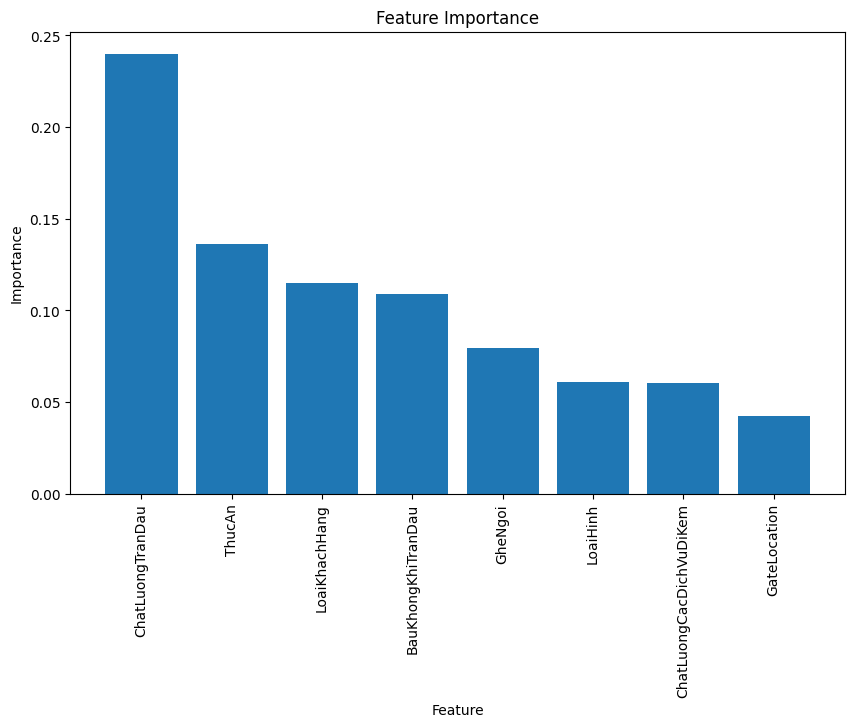

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(feature_importance_df['Feature'].head(8), feature_importance_df['Importance'].head(8))
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.xticks(rotation=90)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=10)
rf.fit(X_train, Y_train)

RandomForestClassifier(random_state=10)

In [ ]:
Y_pred = rf.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)

print(f'Accuracy: {accuracy:.2f}')
print(f'F1 Score: {f1:.2f}')
print(f'Recall: {recall:.2f}')
print(f'Precision: {precision:.2f}')

Accuracy: 0.92
F1 Score: 0.91
Recall: 0.90
Precision: 0.92


In [ ]:
print(rf.n_estimators)

100


In [ ]:
important_features = rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': important_features})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

                    Feature  Importance
7          ChatLuongTranDau    0.120103
6        BauKhongKhiTranDau    0.108775
3                    ThucAn    0.103667
0                      Tuoi    0.078387
9   ChatLuongCacDichVuDiKem    0.066770
15            LoaiKhachHang    0.066271
2                   GheNgoi    0.059154
13                FanDoiNha    0.056717
4              GateLocation    0.051336
11                 ThoiTiet    0.051055
16                 LoaiHinh    0.042210
1                 DoTrePhut    0.040476
5               DichVuGuiXe    0.040063
12                 SuSachSe    0.036276
8     TraiNghiemDatVeOnline    0.031578
10                 DoAnToan    0.030086
14             ThietKeLoiDi    0.017077


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'ChatLuongTranDau'),
  Text(1, 0, 'BauKhongKhiTranDau'),
  Text(2, 0, 'ThucAn'),
  Text(3, 0, 'Tuoi'),
  Text(4, 0, 'ChatLuongCacDichVuDiKem'),
  Text(5, 0, 'LoaiKhachHang'),
  Text(6, 0, 'GheNgoi'),
  Text(7, 0, 'FanDoiNha')])

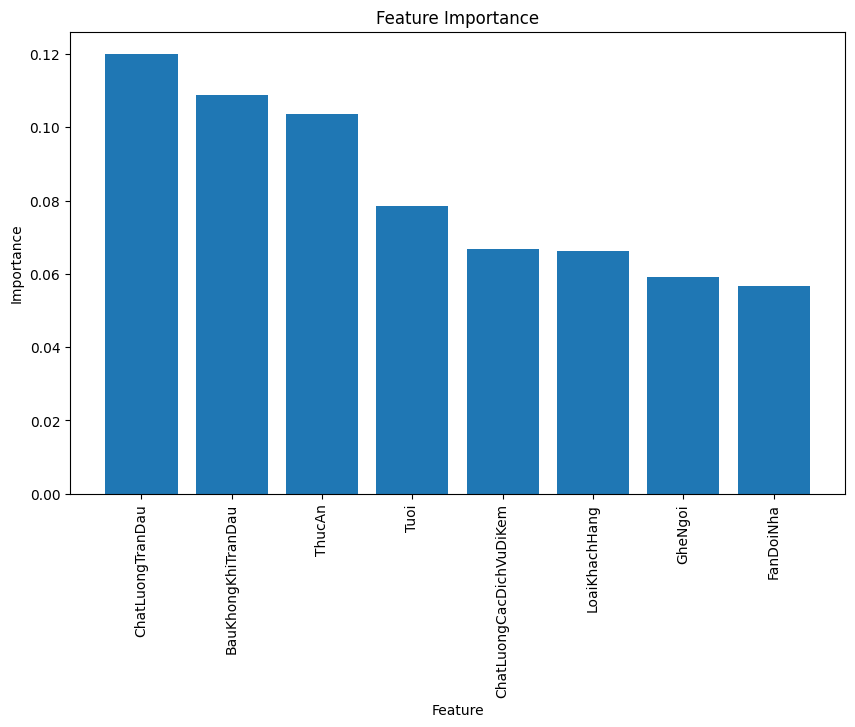

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(feature_importance_df['Feature'].head(8), feature_importance_df['Importance'].head(8))
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.xticks(rotation=90)